In [ ]:
!pip install photutils
!pip install astroalign

from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, CircularAnnulus, ApertureStats, aperture_photometry
import astroalign as aa
import numpy as np
import matplotlib.pyplot as plt

fits_file = fits.open("M41.fits")
imgB = fits_file[0].data.astype(float)   # Blue
imgR = fits_file[1].data.astype(float)   # Red
imgG = fits_file[2].data.astype(float)   # Green (referencia)

print(imgB.shape, imgR.shape, imgG.shape)

(2080, 3096) (2080, 3096) (2080, 3096)


In [ ]:
# encontrar transformaciones hacia el sistema de Verde
tform_B, _ = aa.find_transform(imgB, imgG)
tform_R, _ = aa.find_transform(imgR, imgG)

# aplicar transformaciones (warp) para que queden pixel-a-pixel con Verde
imgB, _ = aa.apply_transform(tform_B, imgB, imgG)
imgR, _ = aa.apply_transform(tform_R, imgR, imgG)

print("Alineación lista.")

Alineación lista.


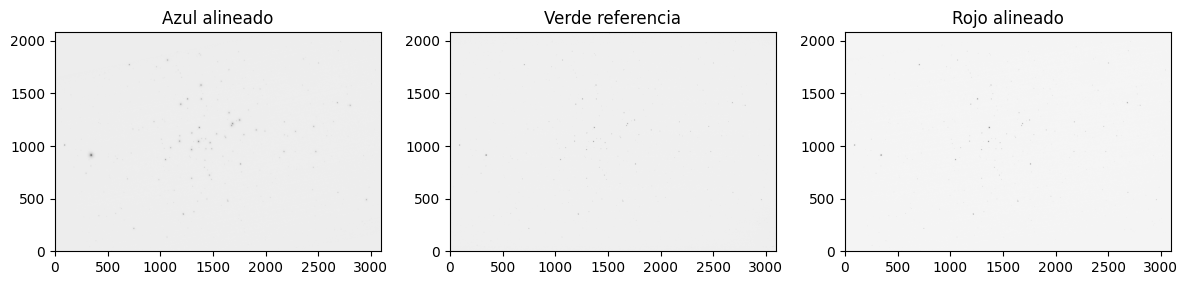

In [ ]:
# Confirmación visual de la alineación de los datos

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(imgB, cmap="Greys", norm=LogNorm(), origin="lower"); plt.title("Azul alineado")
plt.subplot(1,3,2); plt.imshow(imgG, cmap="Greys", norm=LogNorm(), origin="lower"); plt.title("Verde referencia")
plt.subplot(1,3,3); plt.imshow(imgR, cmap="Greys", norm=LogNorm(), origin="lower"); plt.title("Rojo alineado")
plt.tight_layout()
plt.show()

N estrellas detectadas en Verde: 693


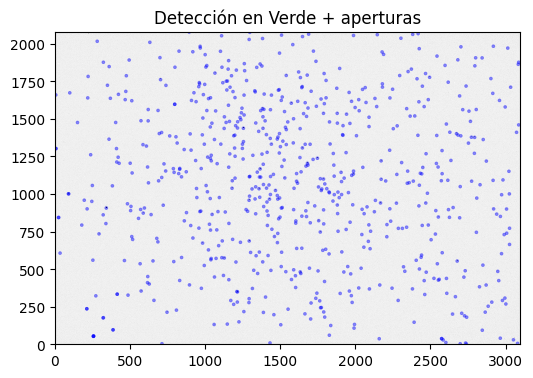

In [ ]:
meanG, medianG, stdG = sigma_clipped_stats(imgG, sigma=3.0)

daofind = DAOStarFinder(fwhm=3.0, threshold=5.0 * stdG)

mask = np.zeros(imgG.shape, dtype=bool)  # igual que repo
sources = daofind(imgG - medianG, mask=mask)

xpix = sources["xcentroid"]
ypix = sources["ycentroid"]
positions = np.transpose((xpix, ypix))

apertures = CircularAperture(positions, r=5.0)

print("N estrellas detectadas en Verde:", len(positions))

plt.figure(figsize=(6,5))
plt.imshow(imgG, cmap="Greys", norm=LogNorm(), origin="lower", interpolation="nearest")
apertures.plot(color="blue", lw=1.5, alpha=0.5)
plt.title("Detección en Verde + aperturas")
plt.show()

In [ ]:
annulus_aperture = CircularAnnulus(positions, r_in=10, r_out=15)

def phot_table(section, apertures, annulus):
    aperstats = ApertureStats(section, annulus)
    bkg_mean = aperstats.mean
    aperture_area = apertures.area_overlap(section)
    total_bkg = bkg_mean * aperture_area

    star_data = aperture_photometry(section, apertures)
    star_data["total_bkg"] = total_bkg
    return star_data

star_dataB = phot_table(imgB, apertures, annulus_aperture)
star_dataG = phot_table(imgG, apertures, annulus_aperture)
star_dataR = phot_table(imgR, apertures, annulus_aperture)

print("Listo: star_dataB, star_dataG, star_dataR")

Listo: star_dataB, star_dataG, star_dataR


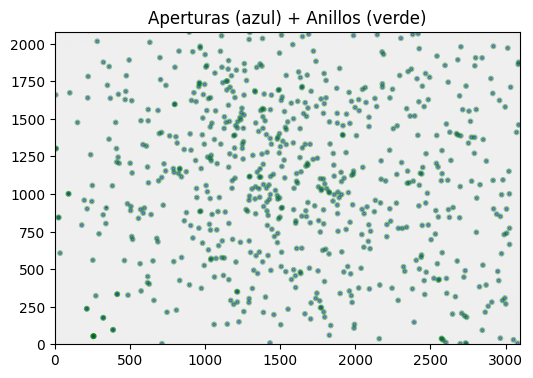

In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(imgG, cmap="Greys", norm=LogNorm(), origin="lower")
apertures.plot(color="blue", lw=1.5, alpha=0.5)
annulus_aperture.plot(color="green", lw=1.0, alpha=0.4)
plt.title("Aperturas (azul) + Anillos (verde)")
plt.show()

In [ ]:
fB = np.array(star_dataB["aperture_sum"], float) - np.array(star_dataB["total_bkg"], float)
fG = np.array(star_dataG["aperture_sum"], float) - np.array(star_dataG["total_bkg"], float)
fR = np.array(star_dataR["aperture_sum"], float) - np.array(star_dataR["total_bkg"], float)

# --- FILTRO POR SNR (mejor que solo flujo > 0) ---

bkgB = np.array(star_dataB["total_bkg"], float)
bkgG = np.array(star_dataG["total_bkg"], float)
bkgR = np.array(star_dataR["total_bkg"], float)

snrB = fB / np.sqrt(np.abs(bkgB))
snrG = fG / np.sqrt(np.abs(bkgG))
snrR = fR / np.sqrt(np.abs(bkgR))

good_snr = (
    np.isfinite(snrB) & np.isfinite(snrG) & np.isfinite(snrR) &
    (snrB > 5) & (snrG > 5) & (snrR > 5)
)

print("Estrellas con SNR > 5 en los 3 filtros:", good_snr.sum(), "de", len(good_snr))

Estrellas con SNR > 5 en los 3 filtros: 576 de 693


In [ ]:
mB_inst = -2.5*np.log10(fB[good_snr])
mG_inst = -2.5*np.log10(fG[good_snr])
mR_inst = -2.5*np.log10(fR[good_snr])

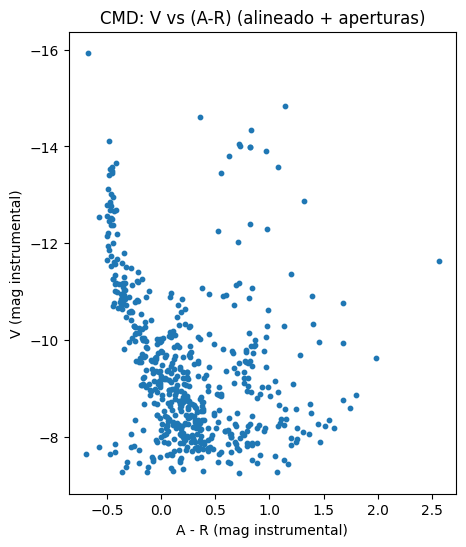

In [ ]:
color_BR = mB_inst - mR_inst

plt.figure(figsize=(5,6))
plt.scatter(color_BR, mG_inst, s=10)
plt.gca().invert_yaxis()
plt.xlabel("A - R (mag instrumental)")
plt.ylabel("V (mag instrumental)")
plt.title("CMD: V vs (A-R) (alineado + aperturas)")
plt.show()